In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa: F401

import segtraq

/home/davids/anaconda3/envs/segtraq-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from pathlib import Path
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa: F401
import warnings
warnings.filterwarnings(action="ignore")
import segtraq
import os

# --- CONFIGURATION: fill in paths before running ---
INPUT_DIR = Path("")              # folder containing per-sample subdirs (input_for_segger)
SEGGER_OUTPUT_BASE_DIR = Path("") # base segger output; with_SC_reference/ and no_SC_reference/ are subdirs
PROSEG_OUTPUT_DIR = Path("")      # proseg output base dir (parent of per-sample subdirs)
SCRNA_REFERENCE_PATH = Path("")   # path to scRNA .h5ad reference
SEGTRAQ_OUTPUT_DIR = Path("")     # output dir for segtraq results

# derived paths (do not edit)
segger_with_SC_path = SEGGER_OUTPUT_BASE_DIR / "with_SC_reference"
segger_no_SC_path = SEGGER_OUTPUT_BASE_DIR / "no_SC_reference"

#defining dataframes to store the metrics for each sample and method
ccs_df = pd.DataFrame(columns=["sample","st_segger_with_sc", "st_segger_no_sc", "raw", "proseg"] )
silhouette_df = pd.DataFrame(columns=["sample","st_segger_with_sc", "st_segger_no_sc", "raw", "proseg"] )
purity_df = pd.DataFrame(columns=["sample","st_segger_with_sc", "st_segger_no_sc", "raw", "proseg"] )
aris_df = pd.DataFrame(columns=["sample","st_segger_with_sc", "st_segger_no_sc", "raw", "proseg"] )

for sample in os.listdir(INPUT_DIR):
    print(f"Processing sample: {sample}")
    os.makedirs(SEGTRAQ_OUTPUT_DIR / sample, exist_ok=True)

    st_segger_with_sc = segtraq.SegTraQ(
        sd.read_zarr(segger_with_SC_path / sample / "segger_spatialdata.zarr"),
        images_key=None,
        tables_area_key=None,
        tables_centroid_x_key="centroid_x",
        tables_centroid_y_key="centroid_y",
        points_background_id=None,
        nucleus_shapes_key=None,
    )

    st_segger_no_sc = segtraq.SegTraQ(
        sd.read_zarr(segger_no_SC_path / sample / "segger_spatialdata.zarr"),
        images_key=None,
        tables_area_key=None,
        tables_centroid_x_key="centroid_x",
        tables_centroid_y_key="centroid_y",
        points_background_id=None,
        nucleus_shapes_key=None,
    )

    st_raw = segtraq.SegTraQ(
        sd.read_zarr(INPUT_DIR / sample / "raw_spatialdata.zarr"),
        images_key=None,
        tables_area_key=None,
        tables_centroid_x_key="centroid_x",
        tables_centroid_y_key="centroid_y",
        points_background_id=None,
        nucleus_shapes_key=None,
    )

    st_proseg = segtraq.SegTraQ(
        sd.read_zarr(PROSEG_OUTPUT_DIR / sample / "proseg-output.zarr"),
        images_key=None,
        tables_area_key=None,
        points_cell_id_key="assignment",
        points_gene_key="gene",
        shapes_cell_id_key="cell",
        tables_centroid_x_key="centroid_x",
        tables_centroid_y_key="centroid_y",
        tables_cell_id_key="cell",
        points_background_id=None,
        nucleus_shapes_key=None,
    )

    st_dict = {"seg_sc": st_segger_with_sc, "seg_no_sc": st_segger_no_sc, "raw": st_raw, "proseg": st_proseg}

    # preprocessing
    for st in st_dict.values():
        adata = st.sdata.tables["table"]
        adata.layers["counts"] = adata.X.copy()
        sc.pp.normalize_total(adata, inplace=True)
        sc.pp.log1p(adata)
        sc.pp.pca(adata)
        sc.pp.neighbors(adata)

    fig, axs = plt.subplots(1, 4, figsize=(8, 2))
    axs = axs.flatten()

    for i, (method, st) in enumerate(st_dict.items()):
        sdata = st.sdata
        adata = sd.deepcopy(sdata.tables["table"])
        sc.tl.umap(adata)
        sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
        sc.pl.umap(
            adata,
            color="leiden",
            ax=axs[i],
            show=False,
            title=method,
            legend_loc=None,
        )

    plt.tight_layout()
    plt.savefig(SEGTRAQ_OUTPUT_DIR / sample / "umap_leiden.png", dpi=300)

    #basic metrics
    ccs = {}
    for method, st in st_dict.items():
        ccs[method] = st.cs.cluster_connectedness(use_weights=True)
    ccs_df.loc[len(ccs_df)] = {"sample": sample, "st_segger_with_sc": ccs["seg_sc"], "st_segger_no_sc": ccs["seg_no_sc"], "raw": ccs["raw"], "proseg": ccs["proseg"]}

    silhouette_scores = {}
    for method, st in st_dict.items():
        silhouette_scores[method] = st.cs.silhouette_score()
    silhouette_df.loc[len(silhouette_df)] = {"sample": sample, "st_segger_with_sc": silhouette_scores["seg_sc"], "st_segger_no_sc": silhouette_scores["seg_no_sc"], "raw": silhouette_scores["raw"], "proseg": silhouette_scores["proseg"]}

    purities = {}
    for method, st in st_dict.items():
        purities[method] = st.cs.purity()
    purity_df.loc[len(purity_df)] = {"sample": sample, "st_segger_with_sc": purities["seg_sc"], "st_segger_no_sc": purities["seg_no_sc"], "raw": purities["raw"], "proseg": purities["proseg"]}

    aris_scores = {}
    for method, st in st_dict.items():
        aris_scores[method] = st.cs.adjusted_rand_index()
    aris_df.loc[len(aris_df)] = {"sample": sample, "st_segger_with_sc": aris_scores["seg_sc"], "st_segger_no_sc": aris_scores["seg_no_sc"], "raw": aris_scores["raw"], "proseg": aris_scores["proseg"]}

    for _, st in st_dict.items():
        adata = st.sdata.tables["table"]
        adata.layers["raw"] = adata.X.copy()
        sc.pp.normalize_total(adata, inplace=True)
        sc.pp.log1p(adata)
        sc.pp.pca(adata)
        sc.pp.neighbors(adata)
        sc.tl.umap(adata)

    adata_ref = ad.read_h5ad(SCRNA_REFERENCE_PATH)

    for _method, st in st_dict.items():
        st.run_label_transfer(
            adata_ref, ref_cell_type="broad_clusters", inplace=True, ref_ensemble_key=None, query_ensemble_key=None
        )

    celltype_proportions = segtraq.pl.celltype_proportions(st_dict, celltype_col="transferred_cell_type", save=SEGTRAQ_OUTPUT_DIR / sample / "celltype_proportions")
    celltype_proportions.to_csv(SEGTRAQ_OUTPUT_DIR / sample / "celltype_proportions.csv", index=False)
    labeled_umap = segtraq.pl.umap(st_dict, color="transferred_cell_type", legend=True, figsize=(11, 8), save=SEGTRAQ_OUTPUT_DIR / sample / "transfered_UMAP")
    labeled_umap.to_csv(SEGTRAQ_OUTPUT_DIR / sample / "labeled_umap.csv", index=False)
    _ = segtraq.pl.umap(st_dict, color="transcript_count", legend=True, figsize=(11, 8), save=SEGTRAQ_OUTPUT_DIR / sample / "UMAP-transcript_count")
    _ = segtraq.pl.boxplot(st_dict, celltype_col="transferred_cell_type", value_key="transcript_count", save=SEGTRAQ_OUTPUT_DIR / sample / "boxplot_transcript_count")
    transcript_count_combined = segtraq.pl.boxplot_combined(st_dict, celltype_col="transferred_cell_type", value_key="transcript_count", save=SEGTRAQ_OUTPUT_DIR / sample / "boxplot_combined")
    transcript_count_combined.to_csv(SEGTRAQ_OUTPUT_DIR / sample / "transcript_count_combined.csv", index=False)

ccs_df.to_csv(SEGTRAQ_OUTPUT_DIR / "ccs_comparison.csv", index=False)
silhouette_df.to_csv(SEGTRAQ_OUTPUT_DIR / "silhouette_comparison.csv", index=False)
purity_df.to_csv(SEGTRAQ_OUTPUT_DIR / "purity_comparison.csv", index=False)
aris_df.to_csv(SEGTRAQ_OUTPUT_DIR / "aris_comparison.csv", index=False)

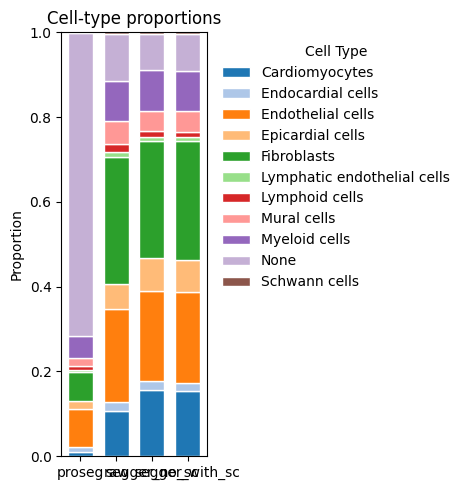

In [6]:
celltype_proportions1 = segtraq.pl.celltype_proportions(st_dict, celltype_col="transferred_cell_type")

In [7]:
celltype_proportions1

,Segmentation Method,Cell Type,Count
0,proseg,Cardiomyocytes,216
1,proseg,Endocardial cells,274
2,proseg,Endothelial cells,1958
3,proseg,Epicardial cells,383
4,proseg,Fibroblasts,1518
5,proseg,Lymphatic endothelial cells,124
6,proseg,Lymphoid cells,167
7,proseg,Mural cells,443
8,proseg,Myeloid cells,1145
9,proseg,None,15650


E ovo je ono što mi je Krešo reko da moram imat, moran znat kokiko je stanica ukupno, ugl sve ove grafove moram imat i u csv formatu, raw data je majka.

In [ ]:
import pandas as pd
df0 = pd.read_csv(SEGTRAQ_OUTPUT_DIR / "33156-Slide-22_A1-1" / "celltype_proportions.csv")
df1 = pd.read_csv(SEGTRAQ_OUTPUT_DIR / "33156-Slide-22_B1-1" / "celltype_proportions.csv")
df2 = pd.read_csv(SEGTRAQ_OUTPUT_DIR / "33156-Slide-22_C1-1" / "celltype_proportions.csv")
df3 = pd.read_csv(SEGTRAQ_OUTPUT_DIR / "33156-Slide-22_D1-1" / "celltype_proportions.csv")


In [3]:
df0.head()

,Segmentation Method,Cell Type,Count
0,proseg,Cardiomyocytes,227
1,proseg,Endocardial cells,52
2,proseg,Endothelial cells,538
3,proseg,Epicardial cells,27
4,proseg,Fibroblasts,217


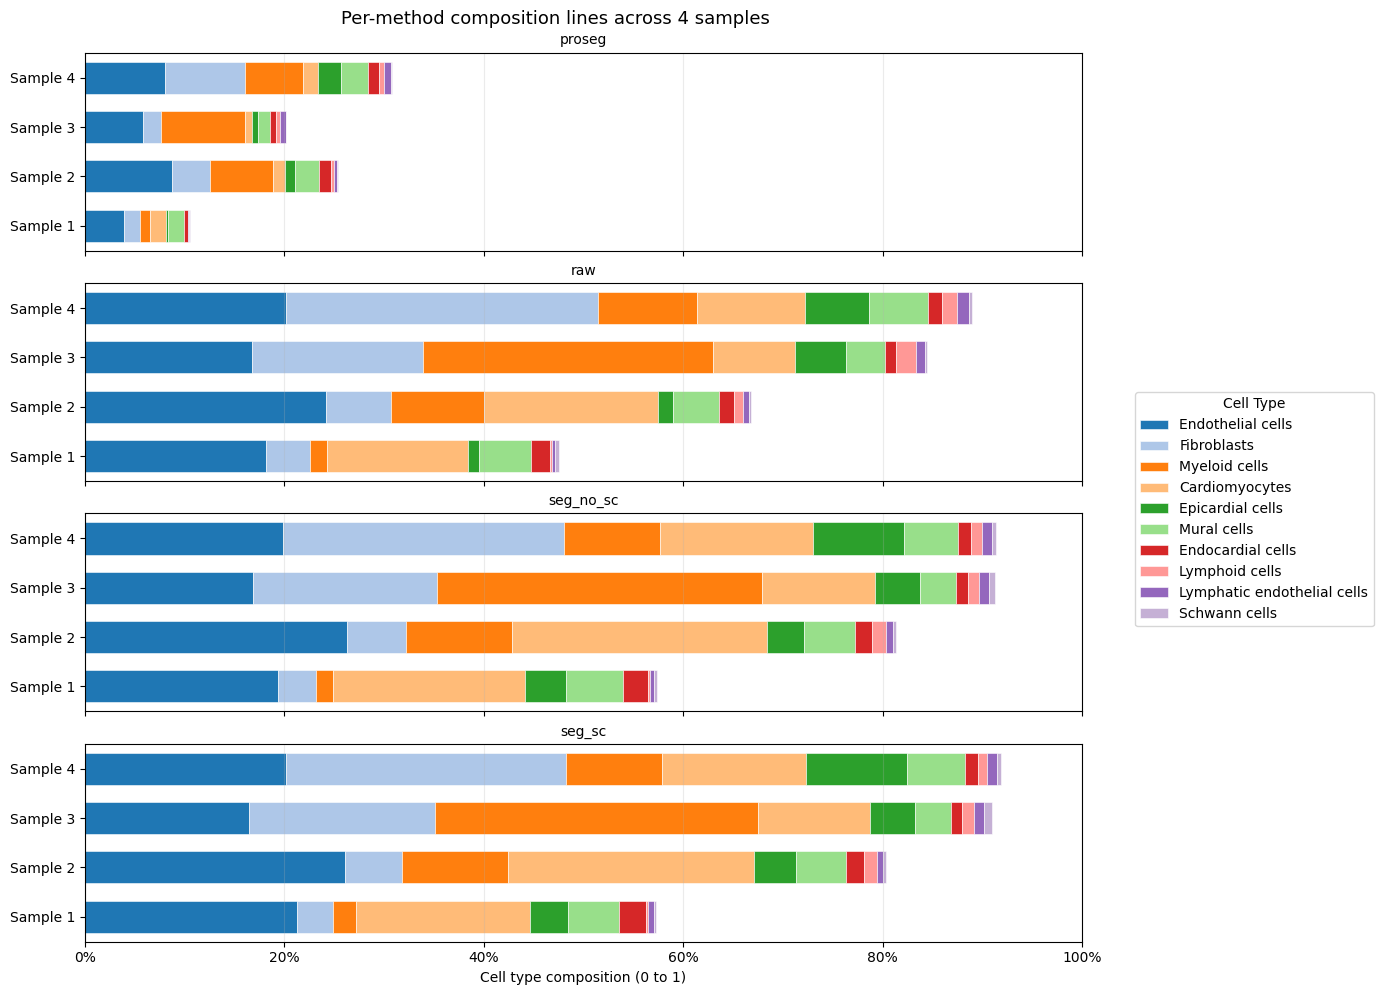

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sample_dfs = {
    "Sample 1": df0,
    "Sample 2": df1,
    "Sample 3": df2,
    "Sample 4": df3,
}

normalized_frames = []
for sample_name, df in sample_dfs.items():
    tmp = df.copy()
    tmp.columns = tmp.columns.str.strip()
    required_columns = ["Segmentation Method", "Cell Type", "Count"]
    missing_columns = [column for column in required_columns if column not in tmp.columns]
    if missing_columns:
        raise ValueError(f"Missing columns in {sample_name}: {missing_columns}")
    tmp["Sample"] = sample_name
    tmp["Fraction"] = tmp["Count"] / tmp.groupby("Segmentation Method")["Count"].transform("sum")
    normalized_frames.append(tmp)

plot_df = pd.concat(normalized_frames, ignore_index=True)

method_order = plot_df["Segmentation Method"].drop_duplicates().tolist()
sample_order = list(sample_dfs.keys())
cell_type_order = (
    plot_df.groupby("Cell Type")["Count"]
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
    if not plot_df.empty
    else []
)

fig, axes = plt.subplots(
    nrows=len(method_order),
    ncols=1,
    figsize=(11, 2.4 * max(1, len(method_order))),
    sharex=True,
    constrained_layout=True,
    squeeze=False,
 )

palette = sns.color_palette("tab20", n_colors=max(1, len(cell_type_order)))

for row_index, method in enumerate(method_order):
    ax = axes[row_index][0]
    method_df = plot_df[plot_df["Segmentation Method"] == method]
    pivot_df = method_df.pivot_table(
        index="Sample",
        columns="Cell Type",
        values="Fraction",
        aggfunc="sum",
        fill_value=0,
    )
    pivot_df = pivot_df.reindex(index=sample_order, columns=cell_type_order, fill_value=0)

    left = [0.0] * len(sample_order)
    for color_index, cell_type in enumerate(cell_type_order):
        values = pivot_df[cell_type].to_numpy()
        ax.barh(
            sample_order,
            values,
            left=left,
            color=palette[color_index % len(palette)],
            edgecolor="white",
            linewidth=0.4,
            label=cell_type if row_index == 0 else None,
            height=0.65,
        )
        left = [l + v for l, v in zip(left, values)]

    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
    ax.grid(axis="x", alpha=0.25)
    ax.set_title(method, fontsize=10)
    ax.set_ylabel("")

axes[-1][0].set_xlabel("Cell type composition (0 to 1)")
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, title="Cell Type", bbox_to_anchor=(1.02, 0.5), loc="center left")
fig.suptitle("Per-method composition lines across 4 samples", y=1.02, fontsize=13)
plt.show()